# Law of Total Probability

The **Law of Total Probability (LOTP)** lets us compute the probability of an event $E$ by breaking it into pieces based on **background events** that partition the sample space.

- **Visual Intuition** — Splitting an event into non-overlapping parts
- **Two-Event Case** — The basic formula with $F$ and $F^C$
- **General LOTP** — Extending to $n$ mutually exclusive background events
- **Disease Testing Example** — Risk groups in a population
- **Weather & Commute Example** — Real-world application
- **Connection to Bayes' Theorem** — LOTP as the denominator
- **Monte Carlo Verification** — Simulating to confirm

**Credits:**
- Stanford CS109: Probability for Computer Scientists
  - [Law of Total Probability](https://chrispiech.github.io/probabilityForComputerScientists/en/part1/law_total/)

## Setup

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.patches import FancyBboxPatch
from matplotlib.colors import to_rgba

from libs.venn import venn, Color

np.random.seed(42)

print("Setup complete!")

Setup complete!


---

## 1. Visual Intuition — Splitting an Event

An astute observation: Any event $E$ can be split into **two non-overlapping parts** based on another event $F$:

- The part of $E$ **inside** $F$: $\;E \cap F$
- The part of $E$ **outside** $F$: $\;E \cap F^C$

Since $F$ and $F^C$ are mutually exclusive and together cover the entire sample space:

$$P(E) = P(E \cap F) + P(E \cap F^C)$$

This works because **every outcome in $E$** must either be in $F$ or in $F^C$ — there's no third option.

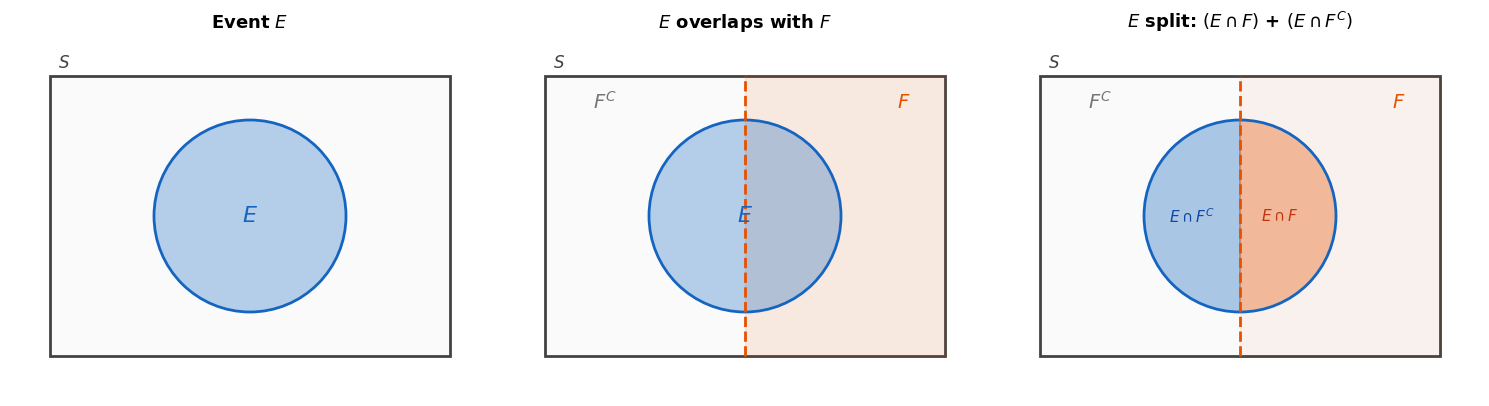

P(E) = P(E ∩ F) + P(E ∩ F^C)
Any event can be decomposed along a partition of the sample space.


In [2]:
# --- Visual: Splitting E into two parts ---

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax in axes:
    ax.set_xlim(-0.5, 5.5)
    ax.set_ylim(-0.5, 4)
    ax.set_aspect('equal')
    ax.axis('off')
    # Sample space
    rect = patches.Rectangle((0, 0), 5, 3.5, linewidth=2,
                              edgecolor='#424242', facecolor='#FAFAFA')
    ax.add_patch(rect)
    ax.text(0.1, 3.6, '$S$', fontsize=12, fontweight='bold', color='#424242')

# Panel 1: E alone
ax = axes[0]
ax.set_title('Event $E$', fontsize=13, fontweight='bold')
e_circle = plt.Circle((2.5, 1.75), 1.2, color='#1565C0', alpha=0.3)
ax.add_patch(e_circle)
e_border = plt.Circle((2.5, 1.75), 1.2, fill=False, edgecolor='#1565C0', lw=2)
ax.add_patch(e_border)
ax.text(2.5, 1.75, '$E$', fontsize=16, ha='center', va='center',
        fontweight='bold', color='#1565C0')

# Panel 2: E and F overlap
ax = axes[1]
ax.set_title('$E$ overlaps with $F$', fontsize=13, fontweight='bold')
# F region (right half)
f_rect = patches.Rectangle((2.5, 0), 2.5, 3.5, color='#E65100', alpha=0.1)
ax.add_patch(f_rect)
ax.plot([2.5, 2.5], [0, 3.5], color='#E65100', lw=2, ls='--')
ax.text(4.4, 3.1, '$F$', fontsize=14, fontweight='bold', color='#E65100')
ax.text(0.6, 3.1, '$F^C$', fontsize=14, fontweight='bold', color='#757575')
# E circle
e_circle = plt.Circle((2.5, 1.75), 1.2, color='#1565C0', alpha=0.3)
ax.add_patch(e_circle)
e_border = plt.Circle((2.5, 1.75), 1.2, fill=False, edgecolor='#1565C0', lw=2)
ax.add_patch(e_border)
ax.text(2.5, 1.75, '$E$', fontsize=16, ha='center', va='center',
        fontweight='bold', color='#1565C0')

# Panel 3: E split into two colored halves
ax = axes[2]
ax.set_title('$E$ split: $(E \\cap F)$ + $(E \\cap F^C)$', fontsize=13, fontweight='bold')
# F region
f_rect = patches.Rectangle((2.5, 0), 2.5, 3.5, color='#E65100', alpha=0.05)
ax.add_patch(f_rect)
ax.plot([2.5, 2.5], [0, 3.5], color='#E65100', lw=2, ls='--')
ax.text(4.4, 3.1, '$F$', fontsize=14, fontweight='bold', color='#E65100')
ax.text(0.6, 3.1, '$F^C$', fontsize=14, fontweight='bold', color='#757575')

# Draw E as two half-circles
theta = np.linspace(-np.pi/2, np.pi/2, 100)
cx, cy, r = 2.5, 1.75, 1.2
# Right half (E ∩ F)
x_right = cx + r * np.cos(theta)
y_right = cy + r * np.sin(theta)
ax.fill(np.append(x_right, cx), np.append(y_right, cy),
        color='#E65100', alpha=0.35)
ax.text(3.0, 1.75, '$E \\cap F$', fontsize=11, ha='center', va='center',
        fontweight='bold', color='#BF360C')

# Left half (E ∩ F^C)
theta2 = np.linspace(np.pi/2, 3*np.pi/2, 100)
x_left = cx + r * np.cos(theta2)
y_left = cy + r * np.sin(theta2)
ax.fill(np.append(x_left, cx), np.append(y_left, cy),
        color='#1565C0', alpha=0.35)
ax.text(1.9, 1.75, '$E \\cap F^C$', fontsize=11, ha='center', va='center',
        fontweight='bold', color='#0D47A1')

# Circle border
e_border = plt.Circle((2.5, 1.75), 1.2, fill=False, edgecolor='#1565C0', lw=2)
ax.add_patch(e_border)

plt.tight_layout()
plt.show()

print("P(E) = P(E ∩ F) + P(E ∩ F^C)")
print("Any event can be decomposed along a partition of the sample space.")

---

## 2. Deriving LOTP — Combining with the Chain Rule

We already know:

$$P(E) = P(E \cap F) + P(E \cap F^C)$$

Now apply the **chain rule** to each term:

$$P(E \cap F) = P(E|F) \cdot P(F)$$
$$P(E \cap F^C) = P(E|F^C) \cdot P(F^C)$$

Substituting:

> **Law of Total Probability (two events):**
>
> $$\boxed{P(E) = P(E|F) \cdot P(F) + P(E|F^C) \cdot P(F^C)}$$

This is useful because we often **know** $P(E|F)$ and $P(E|F^C)$ even when $P(E)$ alone is hard to compute directly.

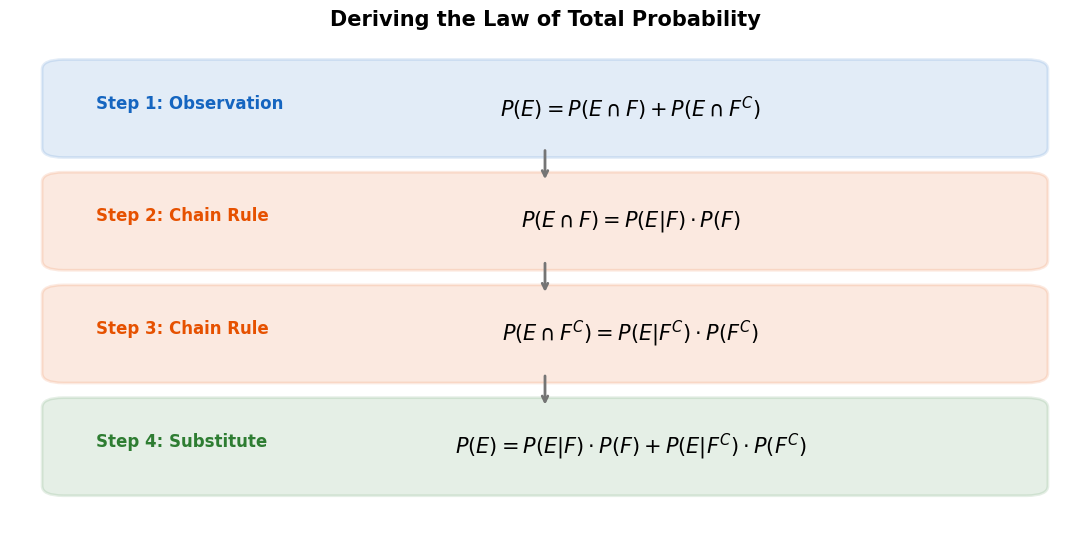

In [3]:
# --- Visual: Step-by-step derivation ---

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.axis('off')

steps = [
    ('Step 1: Observation', r'$P(E) = P(E \cap F) + P(E \cap F^C)$'),
    ('Step 2: Chain Rule', r'$P(E \cap F) = P(E|F) \cdot P(F)$'),
    ('Step 3: Chain Rule', r'$P(E \cap F^C) = P(E|F^C) \cdot P(F^C)$'),
    ('Step 4: Substitute', r'$P(E) = P(E|F) \cdot P(F) + P(E|F^C) \cdot P(F^C)$'),
]

colors = ['#1565C0', '#E65100', '#E65100', '#2E7D32']

for i, (label, formula) in enumerate(steps):
    y = 0.84 - i * 0.23
    rect = FancyBboxPatch((0.05, y - 0.06), 0.9, 0.16,
        boxstyle='round,pad=0.02', facecolor=colors[i], alpha=0.12,
        edgecolor=colors[i], linewidth=2)
    ax.add_patch(rect)
    ax.text(0.08, y + 0.02, label, fontsize=12, fontweight='bold',
            color=colors[i], transform=ax.transAxes)
    ax.text(0.58, y + 0.02, formula, fontsize=15,
            ha='center', va='center', transform=ax.transAxes)

for i in range(3):
    y_start = 0.84 - i * 0.23 - 0.06
    y_end = 0.84 - (i + 1) * 0.23 + 0.10
    ax.annotate('', xy=(0.5, y_end), xytext=(0.5, y_start),
                xycoords='axes fraction', textcoords='axes fraction',
                arrowprops=dict(arrowstyle='->', color='#757575', lw=2))

ax.set_title('Deriving the Law of Total Probability', fontsize=15, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---

## 3. Venn Diagram View

Let's see LOTP through a Venn diagram. Event $E$ straddles the boundary of $F$, so its probability is the sum of two pieces.

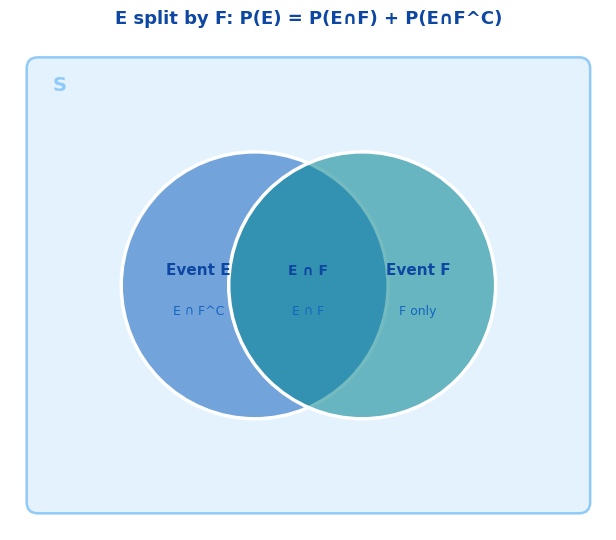

P(E ∩ F)  = 0.1
P(E ∩ F^C) = 0.15
P(E)       = 0.1 + 0.15 = 0.25

LOTP form:
  P(E|F)·P(F) + P(E|F^C)·P(F^C)
  = 0.2857·0.35 + 0.2308·0.65
  = 0.1000 + 0.1500
  = 0.2500  ✓


In [4]:
# --- Venn diagram: E split by F ---

venn("""
venn-beta
    title "E split by F: P(E) = P(E∩F) + P(E∩F^C)"
    set E["Event E"]
        text e1["E ∩ F^C"]
    set F["Event F"]
        text f1["F only"]
    union E, F["E ∩ F"]
        text ef1["E ∩ F"]
""", color_scheme=Color.OCEAN)

# Numeric verification
P_E_and_F = 0.10
P_E_and_Fc = 0.15  # P(E only) = P(E) - P(E∩F) = 0.25 - 0.10
P_E = P_E_and_F + P_E_and_Fc

print(f"P(E ∩ F)  = {P_E_and_F}")
print(f"P(E ∩ F^C) = {P_E_and_Fc}")
print(f"P(E)       = {P_E_and_F} + {P_E_and_Fc} = {P_E}")
print()

# Using LOTP form
P_F = 0.35     # P(F) = P(F only) + P(E∩F) = 0.25 + 0.10
P_Fc = 1 - P_F
P_E_given_F = P_E_and_F / P_F
P_E_given_Fc = P_E_and_Fc / P_Fc

P_E_lotp = P_E_given_F * P_F + P_E_given_Fc * P_Fc

print(f"LOTP form:")
print(f"  P(E|F)·P(F) + P(E|F^C)·P(F^C)")
print(f"  = {P_E_given_F:.4f}·{P_F} + {P_E_given_Fc:.4f}·{P_Fc:.2f}")
print(f"  = {P_E_given_F * P_F:.4f} + {P_E_given_Fc * P_Fc:.4f}")
print(f"  = {P_E_lotp:.4f}  ✓")

---

## 4. A Concrete Example — Rainy Day Commute

Suppose you want to know: **What is the probability of being late to work?**

You know:
- $P(\text{Rain}) = 0.3$
- $P(\text{Late} | \text{Rain}) = 0.5$ — heavy traffic in rain
- $P(\text{Late} | \text{No Rain}) = 0.1$ — smooth commute otherwise

Apply LOTP:

$$P(\text{Late}) = P(\text{Late}|\text{Rain}) \cdot P(\text{Rain}) + P(\text{Late}|\text{No Rain}) \cdot P(\text{No Rain})$$

In [5]:
# --- Rainy day commute ---

P_rain = 0.3
P_no_rain = 1 - P_rain
P_late_given_rain = 0.5
P_late_given_no_rain = 0.1

# LOTP
P_late = P_late_given_rain * P_rain + P_late_given_no_rain * P_no_rain

print("Rainy Day Commute — Law of Total Probability")
print("=" * 50)
print(f"P(Rain)              = {P_rain}")
print(f"P(Late | Rain)       = {P_late_given_rain}")
print(f"P(Late | No Rain)    = {P_late_given_no_rain}")
print()
print(f"P(Late) = P(Late|Rain)·P(Rain) + P(Late|No Rain)·P(No Rain)")
print(f"        = ({P_late_given_rain})({P_rain}) + ({P_late_given_no_rain})({P_no_rain})")
print(f"        = {P_late_given_rain * P_rain:.2f} + {P_late_given_no_rain * P_no_rain:.2f}")
print(f"        = {P_late:.2f}")
print(f"\nYou have a {P_late:.0%} chance of being late on any given day.")

Rainy Day Commute — Law of Total Probability
P(Rain)              = 0.3
P(Late | Rain)       = 0.5
P(Late | No Rain)    = 0.1

P(Late) = P(Late|Rain)·P(Rain) + P(Late|No Rain)·P(No Rain)
        = (0.5)(0.3) + (0.1)(0.7)
        = 0.15 + 0.07
        = 0.22

You have a 22% chance of being late on any given day.


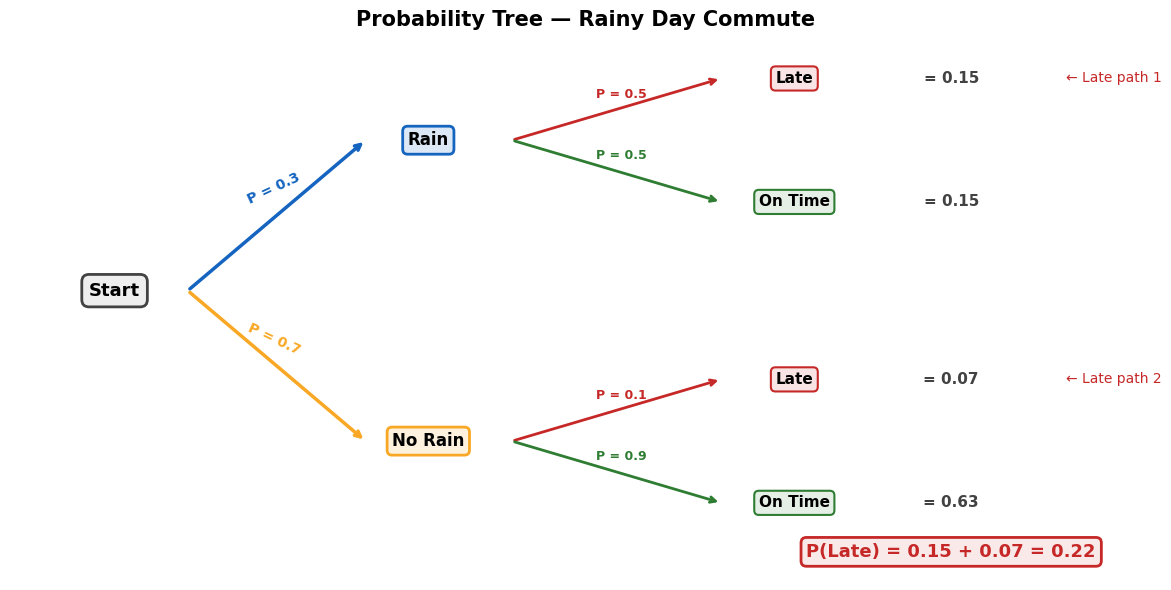

In [6]:
# --- Visual: tree diagram for the commute example ---

fig, ax = plt.subplots(figsize=(12, 6))
ax.axis('off')
ax.set_xlim(-0.5, 10.5)
ax.set_ylim(-0.5, 6.5)

# Colors
c_rain = '#1565C0'
c_sun = '#F9A825'
c_late = '#C62828'
c_on_time = '#2E7D32'

# Root
ax.text(0.5, 3.25, 'Start', fontsize=13, fontweight='bold',
        ha='center', va='center',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='#EEEEEE', edgecolor='#424242', lw=2))

# Level 1: Rain / No Rain
branches_l1 = [
    (3.5, 5.2, 'Rain', c_rain, f'P = {P_rain}'),
    (3.5, 1.3, 'No Rain', c_sun, f'P = {P_no_rain}'),
]

for x, y, label, color, prob in branches_l1:
    ax.annotate('', xy=(x - 0.6, y), xytext=(1.2, 3.25),
                arrowprops=dict(arrowstyle='->', color=color, lw=2.5))
    ax.text(x, y, label, fontsize=12, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=to_rgba(color, 0.15),
                      edgecolor=color, lw=2))
    mid_x = (1.2 + x - 0.6) / 2
    mid_y = (3.25 + y) / 2
    ax.text(mid_x - 0.3, mid_y + 0.15, prob, fontsize=10, color=color,
            fontweight='bold', rotation=25 if y > 3 else -25)

# Level 2: Late / On Time from each branch
branches_l2 = [
    # From Rain
    (7.0, 6.0, 'Late', c_late, f'P = {P_late_given_rain}',
     3.5, 5.2, P_late_given_rain * P_rain),
    (7.0, 4.4, 'On Time', c_on_time, f'P = {1-P_late_given_rain}',
     3.5, 5.2, (1-P_late_given_rain) * P_rain),
    # From No Rain
    (7.0, 2.1, 'Late', c_late, f'P = {P_late_given_no_rain}',
     3.5, 1.3, P_late_given_no_rain * P_no_rain),
    (7.0, 0.5, 'On Time', c_on_time, f'P = {1-P_late_given_no_rain}',
     3.5, 1.3, (1-P_late_given_no_rain) * P_no_rain),
]

for x, y, label, color, prob, sx, sy, joint in branches_l2:
    ax.annotate('', xy=(x - 0.7, y), xytext=(sx + 0.8, sy),
                arrowprops=dict(arrowstyle='->', color=color, lw=2))
    ax.text(x, y, label, fontsize=11, fontweight='bold', ha='center', va='center',
            bbox=dict(boxstyle='round,pad=0.3', facecolor=to_rgba(color, 0.12),
                      edgecolor=color, lw=1.5))
    mid_x = (sx + 0.8 + x - 0.7) / 2
    mid_y = (sy + y) / 2
    ax.text(mid_x - 0.2, mid_y + 0.15, prob, fontsize=9, color=color, fontweight='bold')
    # Joint probability on the right
    ax.text(x + 1.5, y, f'= {joint:.2f}', fontsize=11, ha='center', va='center',
            color='#424242', fontweight='bold')

# Highlight the Late paths
ax.text(9.6, 6.0, '← Late path 1', fontsize=10, color=c_late, va='center')
ax.text(9.6, 2.1, '← Late path 2', fontsize=10, color=c_late, va='center')

# Total
ax.text(8.5, -0.2, f'P(Late) = {P_late_given_rain*P_rain:.2f} + '
        f'{P_late_given_no_rain*P_no_rain:.2f} = {P_late:.2f}',
        fontsize=13, fontweight='bold', color=c_late, ha='center',
        bbox=dict(boxstyle='round,pad=0.3', facecolor=to_rgba(c_late, 0.1),
                  edgecolor=c_late, lw=2))

ax.set_title('Probability Tree — Rainy Day Commute', fontsize=15, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---

## 5. General Law of Total Probability

The two-event case generalizes naturally. If we can divide the sample space into $n$ **mutually exclusive** background events $B_1, B_2, \ldots, B_n$ whose union covers the entire sample space:

> **General LOTP:**
>
> $$\boxed{P(E) = \sum_{i=1}^{n} P(E|B_i) \cdot P(B_i)}$$

**Requirements** for the background events:
1. **Mutually exclusive:** $B_i \cap B_j = \emptyset$ for $i \neq j$
2. **Exhaustive:** $B_1 \cup B_2 \cup \cdots \cup B_n = S$ (the full sample space)

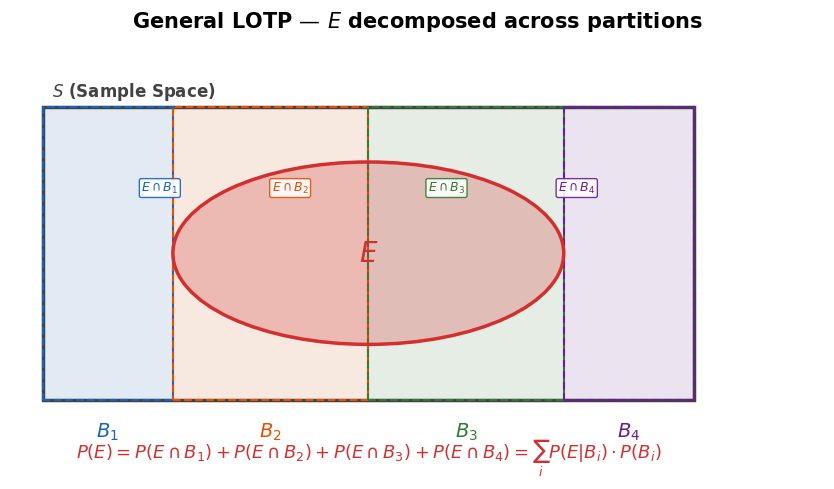

In [7]:
# --- Visual: Sample space partitioned into B1, B2, ..., Bn with E overlapping ---

fig, ax = plt.subplots(figsize=(12, 5))
ax.set_xlim(-0.5, 12)
ax.set_ylim(-1.0, 5.5)
ax.set_aspect('equal')
ax.axis('off')

# Sample space rectangle
W, H = 10, 4.5
rect = patches.Rectangle((0, 0), W, H, linewidth=2.5,
                          edgecolor='#424242', facecolor='#FAFAFA')
ax.add_patch(rect)
ax.text(0.15, 4.65, '$S$ (Sample Space)', fontsize=12, fontweight='bold', color='#424242')

# Partition into 4 vertical stripes (B1 through B4)
partition_colors = ['#1565C0', '#E65100', '#2E7D32', '#6A1B9A']
partition_labels = ['$B_1$', '$B_2$', '$B_3$', '$B_4$']
partition_widths = [2.0, 3.0, 3.0, 2.0]  # varying widths

x_pos = 0
for i, (w, color, label) in enumerate(zip(partition_widths, partition_colors, partition_labels)):
    stripe = patches.Rectangle((x_pos, 0), w, H,
                                facecolor=to_rgba(color, 0.1),
                                edgecolor=color, linewidth=1.5, linestyle='--')
    ax.add_patch(stripe)
    ax.text(x_pos + w/2, -0.5, label, fontsize=14, ha='center', va='center',
            fontweight='bold', color=color)
    x_pos += w

# Event E as an ellipse spanning multiple partitions
from matplotlib.patches import Ellipse
ellipse = Ellipse((5.0, 2.25), 6.0, 2.8, color='#D32F2F', alpha=0.25)
ax.add_patch(ellipse)
ellipse_border = Ellipse((5.0, 2.25), 6.0, 2.8, fill=False,
                          edgecolor='#D32F2F', linewidth=2.5)
ax.add_patch(ellipse_border)
ax.text(5.0, 2.25, '$E$', fontsize=20, ha='center', va='center',
        fontweight='bold', color='#D32F2F')

# Labels for E ∩ Bi inside the ellipse
intersect_positions = [(1.8, 2.25), (3.8, 2.25), (6.2, 2.25), (8.2, 2.25)]
for i, (px, py) in enumerate(intersect_positions):
    label = f'$E \\cap B_{i+1}$'
    ax.text(px, py + 1.0, label, fontsize=9, ha='center', va='center',
            fontweight='bold', color=partition_colors[i],
            bbox=dict(boxstyle='round,pad=0.15', facecolor='white',
                      edgecolor=partition_colors[i], alpha=0.9))

# Formula below
ax.text(5.0, -0.9,
        r'$P(E) = P(E \cap B_1) + P(E \cap B_2) + P(E \cap B_3) + P(E \cap B_4)$'
        r'$ = \sum_{i} P(E|B_i) \cdot P(B_i)$',
        fontsize=13, ha='center', va='center', color='#D32F2F', fontweight='bold')

ax.set_title('General LOTP — $E$ decomposed across partitions',
             fontsize=15, fontweight='bold', pad=10)
plt.tight_layout()
plt.show()

---

## 6. Disease Testing Example — Three Risk Groups

What is the probability that a randomly selected person tests positive for a disease?

The population is partitioned into three **mutually exclusive** risk groups:

| Group | Description | $P(B_i)$ | $P(+ \mid B_i)$ |
|---|---|---|---|
| $B_1$: High-risk | Known exposure | 0.10 | 0.70 |
| $B_2$: Medium-risk | Family history | 0.25 | 0.20 |
| $B_3$: Low-risk | General population | 0.65 | 0.02 |

$$P(+) = P(+|B_1) \cdot P(B_1) + P(+|B_2) \cdot P(B_2) + P(+|B_3) \cdot P(B_3)$$

In [8]:
# --- Disease testing with 3 risk groups ---

groups = ['High-risk (B₁)', 'Medium-risk (B₂)', 'Low-risk (B₃)']
P_B = np.array([0.10, 0.25, 0.65])          # P(B_i)
P_pos_given_B = np.array([0.70, 0.20, 0.02]) # P(+|B_i)

# LOTP
contributions = P_pos_given_B * P_B
P_positive = contributions.sum()

print("Disease Testing — Law of Total Probability")
print("=" * 55)
print(f"{'Group':<22}  {'P(B_i)':>8}  {'P(+|B_i)':>9}  {'Contribution':>13}")
print("-" * 55)
for g, pb, ppb, c in zip(groups, P_B, P_pos_given_B, contributions):
    print(f"{g:<22}  {pb:>8.2f}  {ppb:>9.2f}  {c:>13.4f}")
print("-" * 55)
print(f"{'P(+) = Σ':>45}  {P_positive:.4f}")
print(f"\nA random person has a {P_positive:.2%} chance of testing positive.")

Disease Testing — Law of Total Probability
Group                     P(B_i)   P(+|B_i)   Contribution
-------------------------------------------------------
High-risk (B₁)              0.10       0.70         0.0700
Medium-risk (B₂)            0.25       0.20         0.0500
Low-risk (B₃)               0.65       0.02         0.0130
-------------------------------------------------------
                                     P(+) = Σ  0.1330

A random person has a 13.30% chance of testing positive.


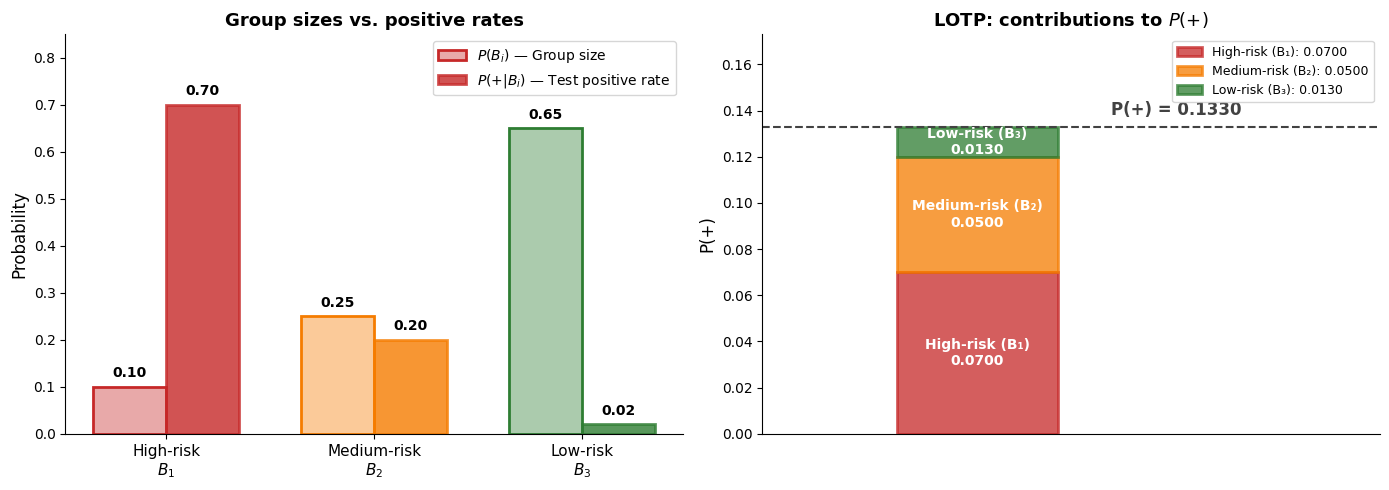


High-risk contributes 52.6% of all positives.
Medium-risk contributes 37.6% of all positives.
Low-risk contributes 9.8% of all positives.


In [9]:
# --- Visual: stacked bar showing each group's contribution ---

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bar_colors = ['#C62828', '#F57C00', '#2E7D32']

# Panel 1: Side-by-side: P(B_i) vs P(+|B_i)
ax = axes[0]
x = np.arange(len(groups))
width = 0.35
bars1 = ax.bar(x - width/2, P_B, width, label='$P(B_i)$ — Group size',
               color=[to_rgba(c, 0.4) for c in bar_colors], edgecolor=bar_colors, lw=2)
bars2 = ax.bar(x + width/2, P_pos_given_B, width, label='$P(+|B_i)$ — Test positive rate',
               color=bar_colors, alpha=0.8, edgecolor=bar_colors, lw=2)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['High-risk\n$B_1$', 'Medium-risk\n$B_2$', 'Low-risk\n$B_3$'], fontsize=11)
ax.set_ylabel('Probability', fontsize=12)
ax.legend(fontsize=10)
ax.set_title('Group sizes vs. positive rates', fontsize=13, fontweight='bold')
ax.set_ylim(0, 0.85)
ax.spines[['top', 'right']].set_visible(False)

# Panel 2: Stacked contribution to P(+)
ax = axes[1]
bottom = 0
for i, (g, c, color) in enumerate(zip(groups, contributions, bar_colors)):
    bar = ax.bar(0, c, 0.6, bottom=bottom, color=color, alpha=0.75,
                 edgecolor=color, lw=2, label=f'{g}: {c:.4f}')
    ax.text(0, bottom + c/2, f'{g}\n{c:.4f}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white')
    bottom += c

ax.axhline(y=P_positive, color='#424242', linestyle='--', lw=1.5)
ax.text(0.5, P_positive + 0.005, f'P(+) = {P_positive:.4f}', fontsize=12,
        fontweight='bold', color='#424242')
ax.set_xlim(-0.8, 1.5)
ax.set_ylim(0, P_positive + 0.04)
ax.set_ylabel('P(+)', fontsize=12)
ax.set_xticks([])
ax.set_title('LOTP: contributions to $P(+)$', fontsize=13, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nHigh-risk contributes {contributions[0]/P_positive:.1%} of all positives.")
print(f"Medium-risk contributes {contributions[1]/P_positive:.1%} of all positives.")
print(f"Low-risk contributes {contributions[2]/P_positive:.1%} of all positives.")

---

## 7. Population Grid — Thinking in Counts

Let's make LOTP tangible by imagining **1000 people** and counting how many test positive in each group.

In [10]:
# --- Population grid: 1000 people ---

N = 1000
group_sizes = (P_B * N).astype(int)   # [100, 250, 650]
positives = (P_pos_given_B * group_sizes).astype(int)  # [70, 50, 13]
negatives = group_sizes - positives

print(f"Population: {N} people")
print(f"{'Group':<18} {'Size':>6} {'Test +':>8} {'Test −':>8}")
print("-" * 42)
for g, s, p, n in zip(groups, group_sizes, positives, negatives):
    print(f"{g:<18} {s:>6} {p:>8} {n:>8}")
print("-" * 42)
total_pos = positives.sum()
print(f"{'Total positives':<18} {'':<6} {total_pos:>8}")
print(f"\nP(+) ≈ {total_pos}/{N} = {total_pos/N:.4f}")
print(f"P(+) exact (LOTP) = {P_positive:.4f}")

Population: 1000 people
Group                Size   Test +   Test −
------------------------------------------
High-risk (B₁)        100       70       30
Medium-risk (B₂)      250       50      200
Low-risk (B₃)         650       13      637
------------------------------------------
Total positives                133

P(+) ≈ 133/1000 = 0.1330
P(+) exact (LOTP) = 0.1330


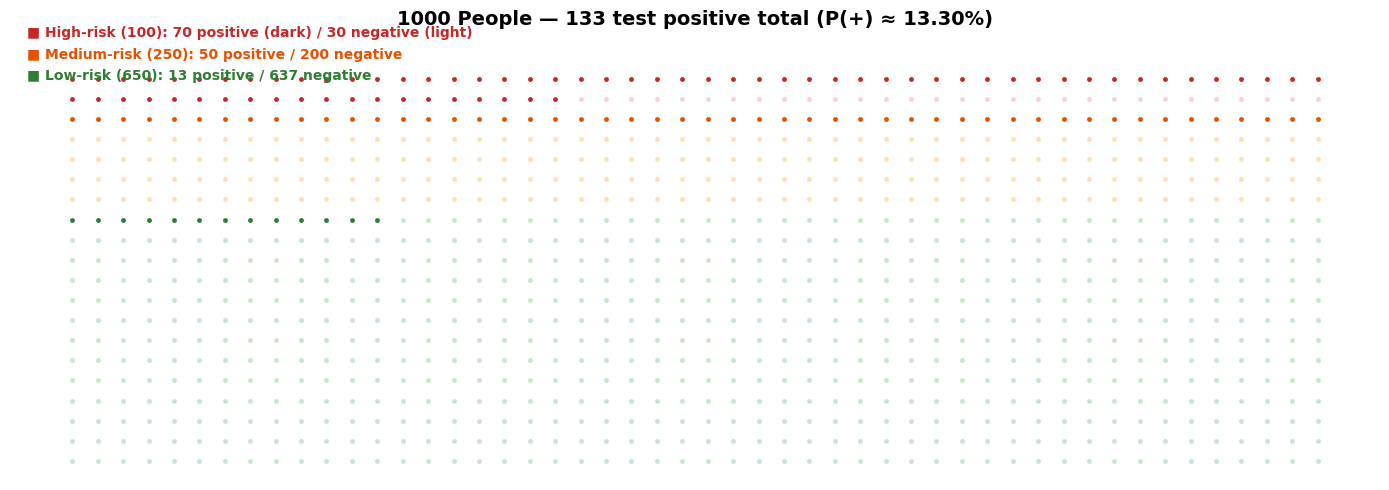

In [11]:
# --- Visual: dot grid of 1000 people ---

fig, ax = plt.subplots(figsize=(14, 5))
ax.axis('off')

dot_colors_map = {
    'high_pos': '#C62828', 'high_neg': '#FFCDD2',
    'med_pos': '#E65100', 'med_neg': '#FFE0B2',
    'low_pos': '#2E7D32', 'low_neg': '#C8E6C9',
}

# Layout: 50 cols x 20 rows = 1000 dots
cols, rows = 50, 20
dot_list = []

# Build ordered list: high-risk (pos then neg), medium, low
dot_list += ['high_pos'] * positives[0] + ['high_neg'] * negatives[0]
dot_list += ['med_pos'] * positives[1] + ['med_neg'] * negatives[1]
dot_list += ['low_pos'] * positives[2] + ['low_neg'] * negatives[2]

for idx, d in enumerate(dot_list):
    col = idx % cols
    row = idx // cols
    ax.plot(col * 0.28, (rows - 1 - row) * 0.28, 'o', color=dot_colors_map[d],
            markersize=3.5, markeredgewidth=0)

# Group labels
ax.text(-0.5, rows * 0.28 + 0.3,
        f'■ High-risk ({group_sizes[0]}): {positives[0]} positive (dark) / {negatives[0]} negative (light)',
        fontsize=10, color='#C62828', fontweight='bold')
ax.text(-0.5, rows * 0.28 + 0.0,
        f'■ Medium-risk ({group_sizes[1]}): {positives[1]} positive / {negatives[1]} negative',
        fontsize=10, color='#E65100', fontweight='bold')
ax.text(-0.5, rows * 0.28 - 0.3,
        f'■ Low-risk ({group_sizes[2]}): {positives[2]} positive / {negatives[2]} negative',
        fontsize=10, color='#2E7D32', fontweight='bold')

ax.set_title(f'1000 People — {total_pos} test positive total (P(+) ≈ {total_pos/N:.2%})',
             fontsize=14, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()

---

## 8. Why LOTP Matters — When Direct Computation is Hard

Sometimes computing $P(E)$ directly is difficult or impossible, but computing $P(E|B_i)$ for each "scenario" $B_i$ is straightforward.

### Example: Rolling Two Dice

What is $P(\text{sum} \geq 10)$?

We can condition on the first die:

$$P(\text{sum} \geq 10) = \sum_{d_1=1}^{6} P(\text{sum} \geq 10 \mid D_1 = d_1) \cdot P(D_1 = d_1)$$

In [12]:
# --- LOTP for dice sum ---

target = 10

print(f"P(sum ≥ {target}) via LOTP, conditioning on D₁")
print("=" * 55)

total = 0
P_d1 = 1/6  # each face equally likely

results = []
for d1 in range(1, 7):
    # For D2 in {1,...,6}, count how many give sum >= target
    needed = target - d1  # D2 needs to be >= this
    favorable = max(0, 6 - max(needed, 1) + 1)
    p_given_d1 = favorable / 6
    contribution = p_given_d1 * P_d1
    total += contribution
    results.append((d1, needed, favorable, p_given_d1, contribution))
    print(f"  D₁={d1}: need D₂≥{needed:>2} → {favorable}/6 ways → "
          f"P(sum≥{target}|D₁={d1})={p_given_d1:.4f}  "
          f"× P(D₁={d1})={P_d1:.4f}  = {contribution:.4f}")

print(f"\n  P(sum ≥ {target}) = {total:.4f} = {total} = {int(round(total*36))}/36")

# Verify by brute force
brute = sum(1 for d1 in range(1,7) for d2 in range(1,7) if d1+d2 >= target) / 36
print(f"  Brute force:        {brute:.4f} = {int(round(brute*36))}/36  ✓")

P(sum ≥ 10) via LOTP, conditioning on D₁
  D₁=1: need D₂≥ 9 → 0/6 ways → P(sum≥10|D₁=1)=0.0000  × P(D₁=1)=0.1667  = 0.0000
  D₁=2: need D₂≥ 8 → 0/6 ways → P(sum≥10|D₁=2)=0.0000  × P(D₁=2)=0.1667  = 0.0000
  D₁=3: need D₂≥ 7 → 0/6 ways → P(sum≥10|D₁=3)=0.0000  × P(D₁=3)=0.1667  = 0.0000
  D₁=4: need D₂≥ 6 → 1/6 ways → P(sum≥10|D₁=4)=0.1667  × P(D₁=4)=0.1667  = 0.0278
  D₁=5: need D₂≥ 5 → 2/6 ways → P(sum≥10|D₁=5)=0.3333  × P(D₁=5)=0.1667  = 0.0556
  D₁=6: need D₂≥ 4 → 3/6 ways → P(sum≥10|D₁=6)=0.5000  × P(D₁=6)=0.1667  = 0.0833

  P(sum ≥ 10) = 0.1667 = 0.16666666666666666 = 6/36
  Brute force:        0.1667 = 6/36  ✓


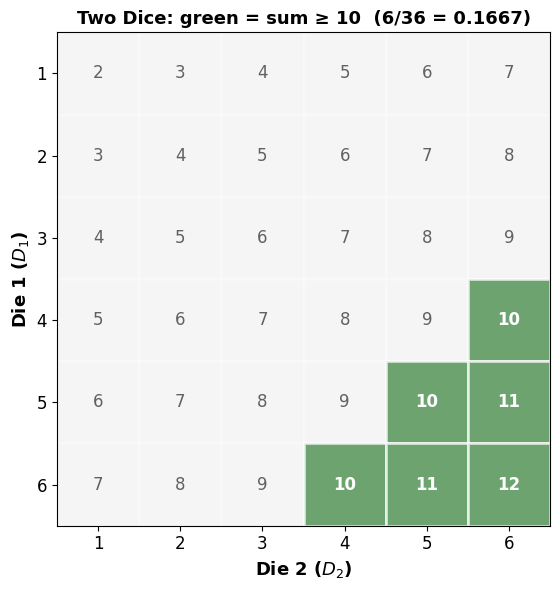

In [13]:
# --- Visual: heatmap of two-dice outcomes ---

fig, ax = plt.subplots(figsize=(7, 6))

grid = np.zeros((6, 6))
for d1 in range(6):
    for d2 in range(6):
        s = (d1 + 1) + (d2 + 1)
        grid[d1][d2] = s

# Color: green if sum >= 10, light gray otherwise
for d1 in range(6):
    for d2 in range(6):
        s = int(grid[d1][d2])
        color = '#2E7D32' if s >= target else '#E0E0E0'
        alpha = 0.7 if s >= target else 0.3
        rect = patches.Rectangle((d2, 5 - d1), 1, 1, facecolor=color,
                                  alpha=alpha, edgecolor='white', lw=2)
        ax.add_patch(rect)
        ax.text(d2 + 0.5, 5. - d1 + 0.5, str(s),
                ha='center', va='center', fontsize=12,
                fontweight='bold' if s >= target else 'normal',
                color='white' if s >= target else '#616161')

ax.set_xlim(0, 6)
ax.set_ylim(0, 6)
ax.set_xticks([i + 0.5 for i in range(6)])
ax.set_xticklabels([str(i) for i in range(1, 7)], fontsize=12)
ax.set_yticks([i + 0.5 for i in range(6)])
ax.set_yticklabels([str(i) for i in range(6, 0, -1)], fontsize=12)
ax.set_xlabel('Die 2 ($D_2$)', fontsize=13, fontweight='bold')
ax.set_ylabel('Die 1 ($D_1$)', fontsize=13, fontweight='bold')
ax.set_title(f'Two Dice: green = sum ≥ {target}  '
             f'({int(round(total*36))}/36 = {total:.4f})',
             fontsize=13, fontweight='bold')
ax.set_aspect('equal')

plt.tight_layout()
plt.show()

---

## 9. Connection to Bayes' Theorem

LOTP is the **denominator** of Bayes' Theorem! Recall:

$$P(B|E) = \frac{P(E|B) \cdot P(B)}{P(E)}$$

When $P(E)$ is not given directly, we expand it using LOTP:

$$P(B|E) = \frac{P(E|B) \cdot P(B)}{\underbrace{P(E|B) \cdot P(B) + P(E|B^C) \cdot P(B^C)}_{\text{Law of Total Probability}}}$$

In the general case with $n$ hypotheses $B_1, \ldots, B_n$:

$$P(B_k|E) = \frac{P(E|B_k) \cdot P(B_k)}{\sum_{i=1}^{n} P(E|B_i) \cdot P(B_i)}$$

Bayes' Theorem using LOTP as denominator
P(+) from LOTP = 0.1330

Given a positive test, which group is the person likely from?

Group                  Prior P(B)   P(+|B)  Posterior
-------------------------------------------------------
High-risk (B₁)               0.10     0.70     0.5263
Medium-risk (B₂)             0.25     0.20     0.3759
Low-risk (B₃)                0.65     0.02     0.0977
-------------------------------------------------------
                             Posterior sum     1.0000

Most likely group: High-risk (B₁) (52.63%)


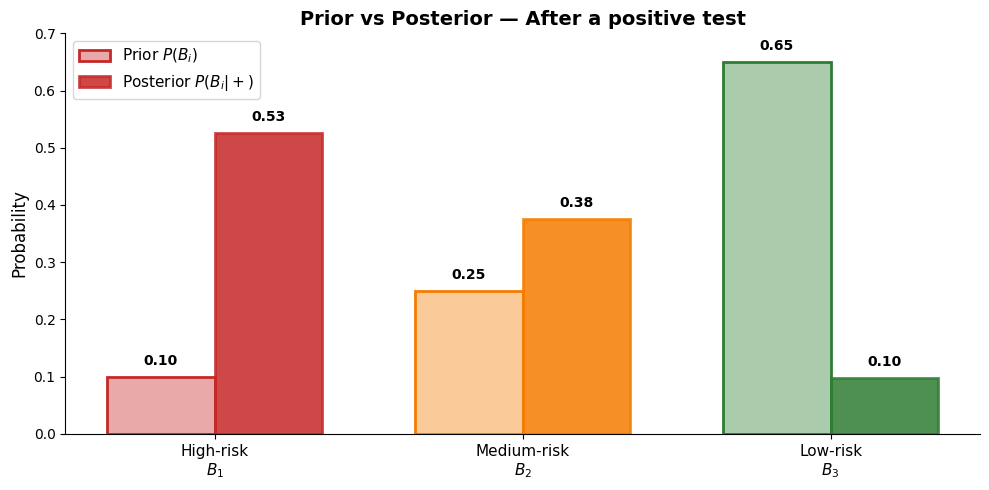

In [14]:
# --- Bayes + LOTP: if someone tests positive, which risk group are they likely from? ---

# Re-use the disease testing values
posteriors = (P_pos_given_B * P_B) / P_positive  # Bayes for each group

print("Bayes' Theorem using LOTP as denominator")
print("=" * 60)
print(f"P(+) from LOTP = {P_positive:.4f}\n")
print(f"Given a positive test, which group is the person likely from?\n")
print(f"{'Group':<22} {'Prior P(B)':>10} {'P(+|B)':>8} {'Posterior':>10}")
print("-" * 55)
for g, pb, ppb, post in zip(groups, P_B, P_pos_given_B, posteriors):
    print(f"{g:<22} {pb:>10.2f} {ppb:>8.2f} {post:>10.4f}")
print("-" * 55)
print(f"{'Posterior sum':>42} {posteriors.sum():>10.4f}")

winner = groups[np.argmax(posteriors)]
print(f"\nMost likely group: {winner} ({posteriors.max():.2%})")

# Visualize prior vs posterior
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(groups))
width = 0.35

ax.bar(x - width/2, P_B, width, label='Prior $P(B_i)$',
       color=[to_rgba(c, 0.4) for c in bar_colors],
       edgecolor=bar_colors, lw=2)
ax.bar(x + width/2, posteriors, width, label='Posterior $P(B_i|+)$',
       color=bar_colors, alpha=0.85, edgecolor=bar_colors, lw=2)

for i, (prior, post) in enumerate(zip(P_B, posteriors)):
    ax.text(i - width/2, prior + 0.02, f'{prior:.2f}', ha='center', fontsize=10, fontweight='bold')
    ax.text(i + width/2, post + 0.02, f'{post:.2f}', ha='center', fontsize=10, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(['High-risk\n$B_1$', 'Medium-risk\n$B_2$', 'Low-risk\n$B_3$'], fontsize=11)
ax.set_ylabel('Probability', fontsize=12)
ax.set_title('Prior vs Posterior — After a positive test', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_ylim(0, 0.7)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---

## 10. LOTP with Varying Partitions

The choice of partition **matters**. The same event $E$ can be decomposed using different background events. Let's see how $P(\text{Late})$ changes as the rain probability varies.

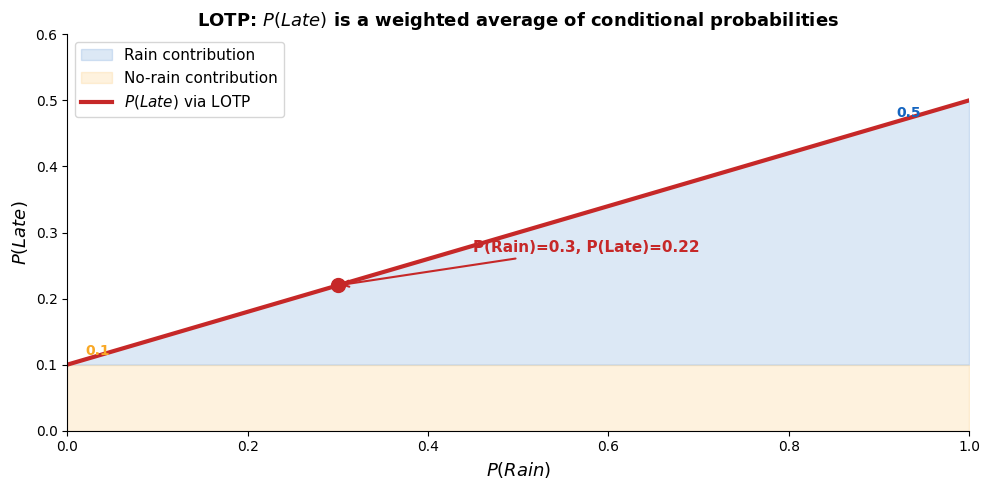

Key insight: P(E) via LOTP is always a WEIGHTED AVERAGE
  of P(E|F)=0.5 and P(E|F^C)=0.1,
  weighted by P(F)=0.3 and P(F^C)=0.7.
  So P(Late) must lie between 0.1 and 0.5.


In [15]:
# --- P(Late) as a function of P(Rain) ---

p_rain_range = np.linspace(0, 1, 200)
p_late_range = P_late_given_rain * p_rain_range + P_late_given_no_rain * (1 - p_rain_range)

fig, ax = plt.subplots(figsize=(10, 5))

ax.fill_between(p_rain_range, P_late_given_no_rain, p_late_range,
                color='#1565C0', alpha=0.15, label='Rain contribution')
ax.fill_between(p_rain_range, 0, P_late_given_no_rain * np.ones_like(p_rain_range),
                color='#F9A825', alpha=0.15, label='No-rain contribution')

ax.plot(p_rain_range, p_late_range, color='#C62828', lw=3, label='$P(Late)$ via LOTP')

# Mark our specific case
ax.plot(P_rain, P_late, 'o', color='#C62828', markersize=10, zorder=5)
ax.annotate(f'P(Rain)={P_rain}, P(Late)={P_late:.2f}',
            xy=(P_rain, P_late), xytext=(P_rain + 0.15, P_late + 0.05),
            fontsize=11, fontweight='bold', color='#C62828',
            arrowprops=dict(arrowstyle='->', color='#C62828', lw=1.5))

# Endpoints
ax.text(0.02, P_late_given_no_rain + 0.015, f'{P_late_given_no_rain}', fontsize=10,
        fontweight='bold', color='#F9A825')
ax.text(0.92, P_late_given_rain - 0.025, f'{P_late_given_rain}', fontsize=10,
        fontweight='bold', color='#1565C0')

ax.set_xlabel('$P(Rain)$', fontsize=13)
ax.set_ylabel('$P(Late)$', fontsize=13)
ax.set_title('LOTP: $P(Late)$ is a weighted average of conditional probabilities',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(0, 1)
ax.set_ylim(0, 0.6)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

print("Key insight: P(E) via LOTP is always a WEIGHTED AVERAGE")
print(f"  of P(E|F)={P_late_given_rain} and P(E|F^C)={P_late_given_no_rain},")
print(f"  weighted by P(F)={P_rain} and P(F^C)={P_no_rain}.")
print(f"  So P(Late) must lie between {P_late_given_no_rain} and {P_late_given_rain}.")

---

## 11. Monte Carlo Simulation

Let's verify LOTP by simulating 500,000 trials of the disease testing scenario.

Monte Carlo Simulation (500,000 people)
  Simulated P(+) = 0.1324
  Exact LOTP P(+) = 0.1330
  |Difference|    = 0.0006

  Group             Simulated P(+|B)   Exact P(+|B)
  --------------------------------------------------
  High-risk (B₁)              0.6952         0.7000
  Medium-risk (B₂)             0.1985         0.2000
  Low-risk (B₃)               0.0203         0.0200


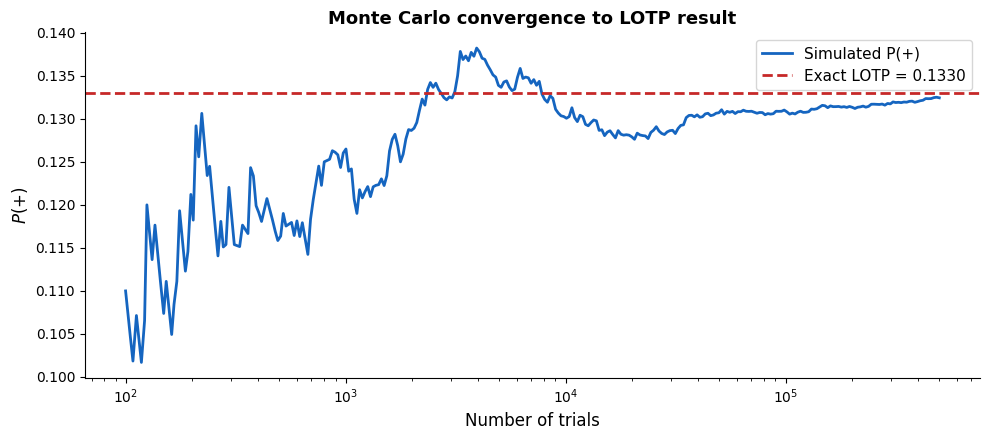

In [16]:
# --- Monte Carlo verification ---

N_sim = 500_000
rng = np.random.default_rng(42)

# Assign each person to a risk group
group_assignment = rng.choice(3, size=N_sim, p=P_B)  # 0=high, 1=med, 2=low

# For each person, determine if they test positive
random_draws = rng.random(N_sim)
test_positive = random_draws < P_pos_given_B[group_assignment]

P_pos_simulated = test_positive.mean()

print(f"Monte Carlo Simulation ({N_sim:,} people)")
print("=" * 50)
print(f"  Simulated P(+) = {P_pos_simulated:.4f}")
print(f"  Exact LOTP P(+) = {P_positive:.4f}")
print(f"  |Difference|    = {abs(P_pos_simulated - P_positive):.4f}")
print()

# Group-by-group verification
print(f"  {'Group':<15} {'Simulated P(+|B)':>18} {'Exact P(+|B)':>14}")
print("  " + "-" * 50)
for i, g in enumerate(groups):
    in_group = group_assignment == i
    sim_rate = test_positive[in_group].mean()
    print(f"  {g:<15} {sim_rate:>18.4f} {P_pos_given_B[i]:>14.4f}")

# Convergence plot
cumulative = np.cumsum(test_positive) / np.arange(1, N_sim + 1)
checkpoints = np.logspace(2, np.log10(N_sim), 300).astype(int)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(checkpoints, cumulative[checkpoints - 1], color='#1565C0', lw=2, label='Simulated P(+)')
ax.axhline(y=P_positive, color='#C62828', ls='--', lw=2, label=f'Exact LOTP = {P_positive:.4f}')
ax.set_xscale('log')
ax.set_xlabel('Number of trials', fontsize=12)
ax.set_ylabel('$P(+)$', fontsize=12)
ax.set_title('Monte Carlo convergence to LOTP result', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---

## 12. Common Pitfalls

| Pitfall | Why it fails |
|---|---|
| Background events **not mutually exclusive** | Double-counting some outcomes |
| Background events **don't cover** the sample space | Missing some outcomes |
| Confusing $P(E \mid B_i)$ with $P(B_i \mid E)$ | The direction of conditioning matters |
| Forgetting to **weight** by $P(B_i)$ | Each partition piece has a different size |

Pitfall: Simple average vs. LOTP (weighted average)
  Simple average of P(+|Bi):  (0.70 + 0.20 + 0.02) / 3 = 0.3067
  LOTP (weighted by P(Bi)):   0.1330
  Error from ignoring weights: 0.1737

The simple average overestimates because it gives equal weight
to the small high-risk group (10%) and the large low-risk group (65%).
LOTP correctly weights each conditional probability by its group size.


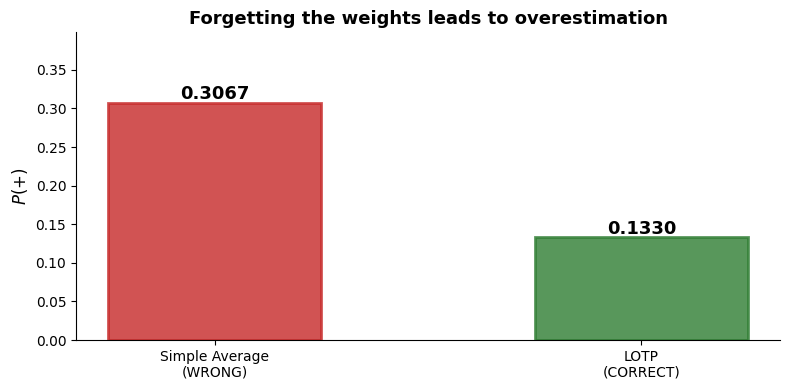

In [17]:
# --- Pitfall demo: What happens if you DON'T weight by P(B_i)? ---

# Wrong: simple average of conditional probabilities
wrong_avg = P_pos_given_B.mean()
# Correct: weighted average (LOTP)
correct = P_positive

print("Pitfall: Simple average vs. LOTP (weighted average)")
print("=" * 55)
print(f"  Simple average of P(+|Bi):  ({' + '.join(f'{p:.2f}' for p in P_pos_given_B)}) / 3 = {wrong_avg:.4f}")
print(f"  LOTP (weighted by P(Bi)):   {correct:.4f}")
print(f"  Error from ignoring weights: {abs(wrong_avg - correct):.4f}")
print()
print("The simple average overestimates because it gives equal weight")
print("to the small high-risk group (10%) and the large low-risk group (65%).")
print("LOTP correctly weights each conditional probability by its group size.")

# Visual comparison
fig, ax = plt.subplots(figsize=(8, 4))
labels = ['Simple Average\n(WRONG)', 'LOTP\n(CORRECT)']
values = [wrong_avg, correct]
colors_bar = ['#C62828', '#2E7D32']

bars = ax.bar(labels, values, color=colors_bar, alpha=0.8, edgecolor=colors_bar, lw=2, width=0.5)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.4f}', ha='center', fontsize=13, fontweight='bold')

ax.set_ylabel('$P(+)$', fontsize=12)
ax.set_title('Forgetting the weights leads to overestimation', fontsize=13, fontweight='bold')
ax.set_ylim(0, max(values) * 1.3)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

---

## 13. Summary

| Concept | Formula |
|---|---|
| **Observation** | $P(E) = P(E \cap F) + P(E \cap F^C)$ |
| **LOTP (two events)** | $P(E) = P(E \mid F) \cdot P(F) + P(E \mid F^C) \cdot P(F^C)$ |
| **General LOTP** | $P(E) = \displaystyle\sum_{i=1}^{n} P(E \mid B_i) \cdot P(B_i)$ |
| **Requirements** | $B_i$ must be mutually exclusive and exhaustive |
| **Bayes connection** | LOTP provides the denominator $P(E)$ in Bayes' Theorem |

### Key Takeaways

1. LOTP decomposes $P(E)$ into a **weighted average** of conditional probabilities
2. The weights are the **sizes** of the background events $P(B_i)$
3. The background events must **partition** the sample space (mutually exclusive + exhaustive)
4. LOTP is most useful when $P(E|B_i)$ is easy to compute but $P(E)$ alone is not
5. LOTP is the **denominator** of Bayes' Theorem — they are inseparable tools